#Importing and cleaning

In [ ]:
#import requests
import pandas as pd
from google.colab import userdata
from pathlib import Path

#all_rows = []
#offset = 0
#length = 5000

#api_key = userdata.get('api_key')

#url = 'https://api.eia.gov/v2/electricity/rto/region-data/data/'


#params = {
 #   'frequency': 'local-hourly',
  #  'data[0]': 'value',
   # 'facets[respondent][]': 'ERCO',
   # 'start': '2019-01-01T00-06:00',
   # 'end': '2025-12-31T00-06:00',
   # 'sort[0][column]': 'period',
   # 'sort[0][direction]': 'desc',
    #'offset': 0,
    #'length': 5000,
    #'api_key': api_key
#}

#while True:
 # params['offset'] = offset
  #params['length'] = length

  #response = requests.get(url, params=params)
  #data = response.json()

  #new_rows = data['response']['data']

  #if len(new_rows) == 0:
   # break

  #all_rows.extend(new_rows)

  #offset = offset + length

#print(response.status_code)
#print(response.text[:500])
#print(response.url)

In [ ]:
#len(all_rows)

In [ ]:
#df_raw = pd.DataFrame(all_rows)
#df_raw.to_csv('eia_erco_region_data_2019_2024_raw.csv', index=False)
#df_raw.head()

In [ ]:
path = '/content/drive/MyDrive/Portfolio/eia_erco_region_data_2019_2024_raw.csv'

df_raw = pd.read_csv(path)
df_raw.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2025-12-31T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,53189,megawatthours
1,2025-12-31T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,53131,megawatthours
2,2025-12-31T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",NG,Net generation,52856,megawatthours
3,2025-12-31T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",TI,Total interchange,-333,megawatthours
4,2025-12-30T23-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,54362,megawatthours


In [ ]:
df_raw.shape

(245248, 7)

In [ ]:
df_raw['type-name'].value_counts()

,count
type-name,
Demand,61344
Net generation,61321
Day-ahead demand forecast,61297
Total interchange,61286


In [ ]:
df_raw['period'].min()

'2019-01-01T00-06'

In [ ]:
df_raw['period'].max()

'2025-12-31T00-06'

In [ ]:
df_raw.duplicated(subset=['period', 'respondent', 'type']).sum()

np.int64(0)

In [ ]:
df_demand = df_raw[df_raw['type'] == 'D'].copy()
df_demand.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2025-12-31T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,53189,megawatthours
4,2025-12-30T23-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,54362,megawatthours
8,2025-12-30T22-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,55464,megawatthours
12,2025-12-30T21-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,55664,megawatthours
16,2025-12-30T20-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,55192,megawatthours


In [ ]:
df_demand['period_utc'] = pd.to_datetime(
    df_demand['period'],
    utc=True # Convert to UTC and set tzinfo
)

df_demand.set_index('period_utc', inplace=True)
df_demand = df_demand.sort_index()
df_demand.head()

/tmp/ipykernel_2198/1623769520.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_demand['period_utc'] = pd.to_datetime(


,period,respondent,respondent-name,type,type-name,value,value-units
period_utc,,,,,,,
2019-01-01 06:00:00+00:00,2019-01-01T00-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37301,megawatthours
2019-01-01 07:00:00+00:00,2019-01-01T01-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,36953,megawatthours
2019-01-01 08:00:00+00:00,2019-01-01T02-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37114,megawatthours
2019-01-01 09:00:00+00:00,2019-01-01T03-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37154,megawatthours
2019-01-01 10:00:00+00:00,2019-01-01T04-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37290,megawatthours


In [ ]:
df_demand.isnull().sum()

,0
period,0
respondent,0
respondent-name,0
type,0
type-name,0
value,0
value-units,0


In [ ]:
df_demand.dtypes

,0
period,object
respondent,object
respondent-name,object
type,object
type-name,object
value,int64
value-units,object


In [ ]:
df_demand['value'] = pd.to_numeric(df_demand['value'], errors='coerce')
df_demand['value'].dtypes

dtype('int64')

In [ ]:
time_gaps = df_demand.index.to_series().diff()
time_gaps.value_counts()

,count
period_utc,
0 days 01:00:00,61342
0 days 02:00:00,1


In [ ]:
time_gaps[time_gaps == pd.Timedelta(hours=2)]

,period_utc
period_utc,
2021-11-07 07:00:00+00:00,0 days 02:00:00


In [ ]:
df_demand.loc['2021-11-06 22:00:00':'2021-11-07 08:00:00']

,period,respondent,respondent-name,type,type-name,value,value-units
period_utc,,,,,,,
2021-11-06 22:00:00+00:00,2021-11-06T17-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,36869,megawatthours
2021-11-06 23:00:00+00:00,2021-11-06T18-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37122,megawatthours
2021-11-07 00:00:00+00:00,2021-11-06T19-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37486,megawatthours
2021-11-07 01:00:00+00:00,2021-11-06T20-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,38232,megawatthours
2021-11-07 02:00:00+00:00,2021-11-06T21-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37876,megawatthours
2021-11-07 03:00:00+00:00,2021-11-06T22-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,37176,megawatthours
2021-11-07 04:00:00+00:00,2021-11-06T23-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,36124,megawatthours
2021-11-07 05:00:00+00:00,2021-11-07T00-05,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,34756,megawatthours
2021-11-07 07:00:00+00:00,2021-11-07T01-06,ERCO,"Electric Reliability Council of Texas, Inc.",D,Demand,33096,megawatthours


Missing an hour due to daylight savings.

In [ ]:
df_demand = df_demand.asfreq('h')
df_demand['value'] = df_demand['value'].interpolate()
df_demand.loc['2021-11-07 06:00:00+00:00']

,2021-11-07 06:00:00+00:00
period,NaN
respondent,NaN
respondent-name,NaN
type,NaN
type-name,NaN
value,33926.0
value-units,NaN


Created a demand-only dataset and removing constants that bloat our dataframe. Feature engineering time features for model training.

In [ ]:
df_model = df_demand[['value']].copy()
df_model['hour'] = df_model.index.hour
df_model['dayofweek'] = df_model.index.dayofweek
df_model['month'] = df_model.index.month
df_model['year'] = df_model.index.year
df_model.head()

,value,hour,dayofweek,month,year
period_utc,,,,,
2019-01-01 06:00:00+00:00,37301.0,6,1,1,2019
2019-01-01 07:00:00+00:00,36953.0,7,1,1,2019
2019-01-01 08:00:00+00:00,37114.0,8,1,1,2019
2019-01-01 09:00:00+00:00,37154.0,9,1,1,2019
2019-01-01 10:00:00+00:00,37290.0,10,1,1,2019


#EDA

In [ ]:
df_model.describe()

,value,hour,dayofweek,month,year
count,61345.000000,61345.000000,61345.000000,61345.000000,61345.000000
mean,48663.711452,11.499910,2.999299,6.521509,2021.999462
std,11163.203875,6.922222,1.999931,3.447861,1.999548
min,27449.000000,0.000000,0.000000,1.000000,2019.000000
25%,40426.000000,6.000000,1.000000,4.000000,2020.000000
50%,46292.000000,11.000000,3.000000,7.000000,2022.000000
75%,54965.000000,17.000000,5.000000,10.000000,2024.000000
max,85544.000000,23.000000,6.000000,12.000000,2025.000000


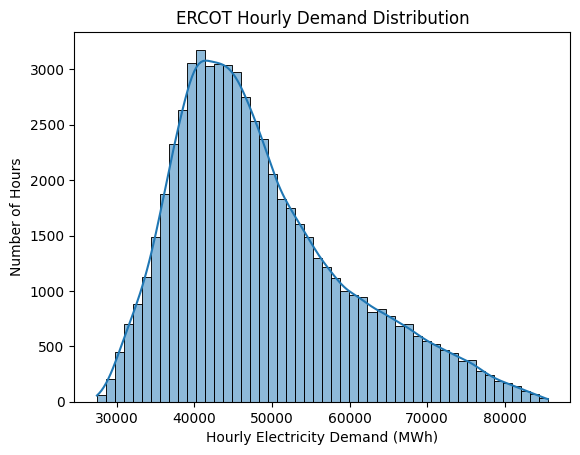

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_model['value'], bins=50, kde=True)

plt.title('ERCOT Hourly Demand Distribution')
plt.xlabel('Hourly Electricity Demand (MWh)')
plt.ylabel('Number of Hours')
plt.show()

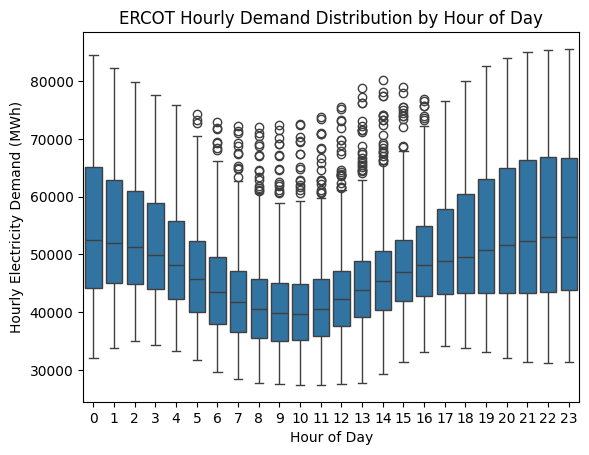

In [ ]:
sns.boxplot(data = df_model, x = 'hour', y = 'value')

plt.title('ERCOT Hourly Demand Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Hourly Electricity Demand (MWh)')
plt.show()

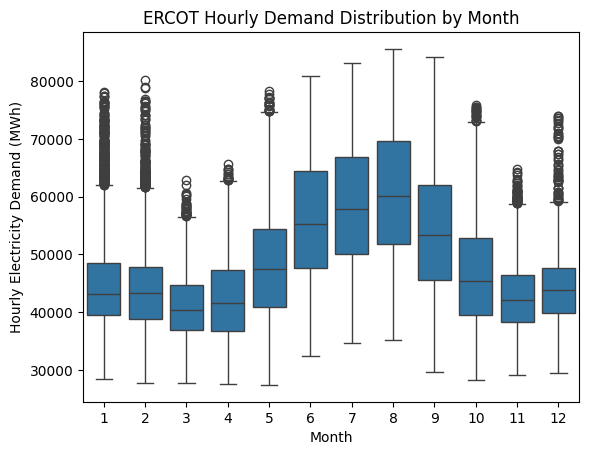

In [ ]:
sns.boxplot(data = df_model, x = 'month', y = 'value')
plt.title('ERCOT Hourly Demand Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Hourly Electricity Demand (MWh)')
plt.show()

Distribution is right-skewed with many outliers. This is expected in energy consumption with differences in weather and seasonal conditions. The outliers will be preserved due to their value in predictions as they are likely normal behaviors.

In [ ]:
yearly_summary = df_model.groupby('year')['value'].agg(
    mean_demand='mean',
    median_demand='median',
    peak_demand='max',
    p95_demand=lambda x: x.quantile(0.95),
    p99_demand=lambda x: x.quantile(0.99),
    peak_avg_ratio = lambda x: x.max() / x.mean(),
    peak_median_ratio = lambda x: x.max() / x.median(),
)

yearly_summary

,mean_demand,median_demand,peak_demand,p95_demand,p99_demand,peak_avg_ratio,peak_median_ratio
year,,,,,,,
2019,43800.186086,41051.0,74533.0,63891.00,70132.68,1.701659,1.815620
2020,43370.134335,40995.0,74166.0,63315.55,70161.19,1.710071,1.809147
2021,44811.919521,42349.5,73476.0,64603.25,70660.61,1.639653,1.734991
2022,49159.162215,46624.0,79830.0,70547.40,76300.38,1.623909,1.712208
2023,51003.874201,47318.0,85432.0,76483.65,82943.87,1.675010,1.805486
2024,52796.284495,49874.5,85544.0,74359.90,80739.10,1.620266,1.715185
2025,55717.958710,53409.0,83597.0,75708.70,80761.24,1.500360,1.565223


All variables show a general trend in increased demand. Median is not affected by outliers like mean and shows an increasing trend in demand.The highs in peaks are different among the years but they are trending upwards. The percentiles help with not focusing on the largest outliers and seeing the trends in overall peaks instead of a single peak for the year. Peak to average is lowering which tells us that we are seeing more demand overall instead of increasing outliers pulling the demand to higher levels.



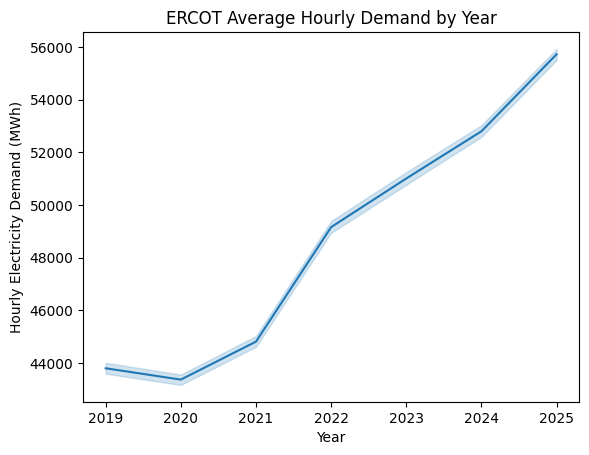

In [ ]:
sns.lineplot(data = df_model, x = 'year', y = 'value')
plt.title('ERCOT Average Hourly Demand by Year')
plt.xlabel('Year')
plt.ylabel('Hourly Electricity Demand (MWh)')
plt.show()

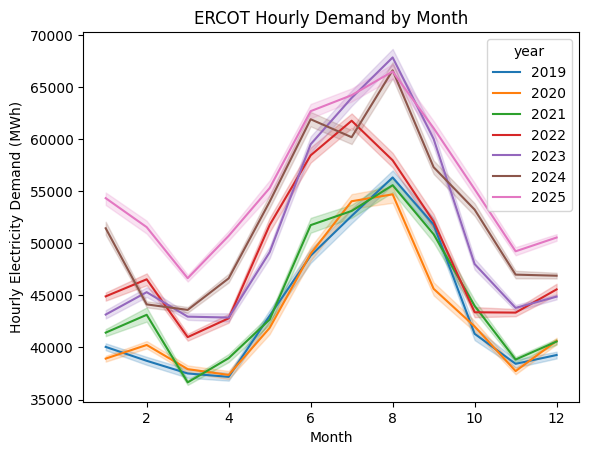

In [ ]:
sns.lineplot(data = df_model, x = 'month', y = 'value', hue = 'year', palette='tab10',)
plt.title('ERCOT Hourly Demand by Month')
plt.xlabel('Month')
plt.ylabel('Hourly Electricity Demand (MWh)')
plt.show()

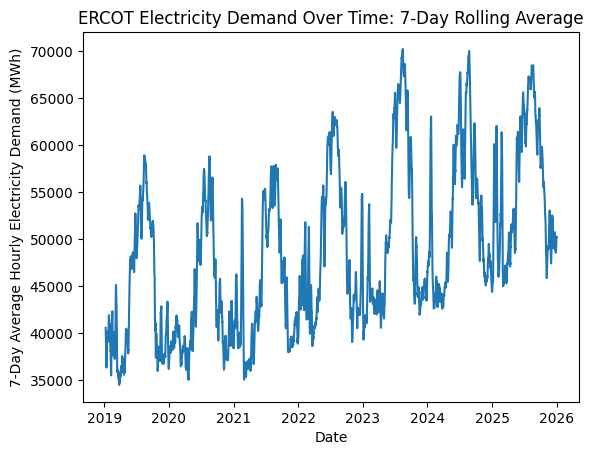

In [ ]:
rolling_7d = df_model['value'].rolling(24 * 7).mean()
sns.lineplot(data = df_model, x = df_model.index, y = rolling_7d)
plt.title('ERCOT Electricity Demand Over Time: 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('7-Day Average Hourly Electricity Demand (MWh)')
plt.show()

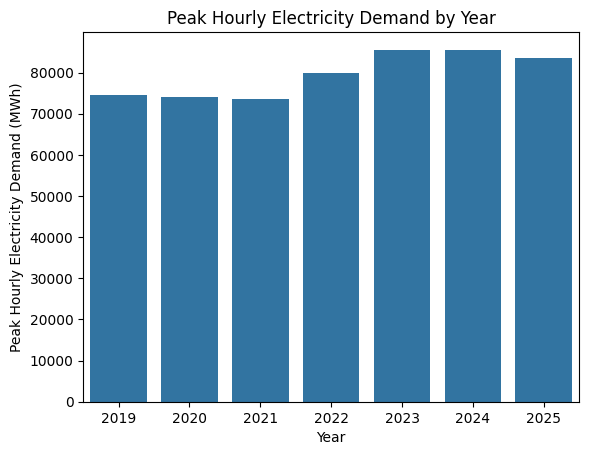

In [ ]:
peak_by_year = df_model.groupby('year')['value'].max()

sns.barplot(x = peak_by_year.index, y = peak_by_year.values)
plt.title('Peak Hourly Electricity Demand by Year')
plt.xlabel('Year')
plt.ylabel('Peak Hourly Electricity Demand (MWh)')
plt.show()

Text(0, 0.5, 'Peak Hourly Electricity Demand (MWh)')

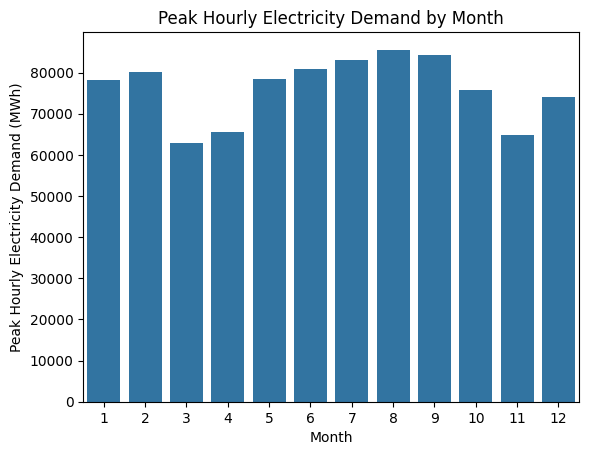

In [ ]:
peak_by_month = df_model.groupby('month')['value'].max()

sns.barplot(x = peak_by_month.index, y = peak_by_month.values)
plt.title('Peak Hourly Electricity Demand by Month')
plt.xlabel('Month')
plt.ylabel('Peak Hourly Electricity Demand (MWh)')

#Feature Engineering

In [ ]:
df_model['lag_1'] = df_model['value'].shift(1)
df_model['lag_24'] = df_model['value'].shift(24)
df_model['lag_168'] = df_model['value'].shift(168)

In [ ]:
df_model['lag_1']

,lag_1
period_utc,
2019-01-01 06:00:00+00:00,NaN
2019-01-01 07:00:00+00:00,37301.0
2019-01-01 08:00:00+00:00,36953.0
2019-01-01 09:00:00+00:00,37114.0
2019-01-01 10:00:00+00:00,37154.0
...,...
2025-12-31 02:00:00+00:00,54666.0
2025-12-31 03:00:00+00:00,55192.0
2025-12-31 04:00:00+00:00,55664.0


Creating lag features to help the model with finding trends not visible without this feature.

In [ ]:
df_model['rolling_mean_24'] = df_model['value'].shift(1).rolling(24).mean()
df_model['rolling_mean_168'] = df_model['value'].shift(1).rolling(168).mean()

Using mean to average across the time period for the model to interpret.

In [ ]:
high_demand_threshold = df_model['value'].quantile(0.95)
extreme_demand_threshold = df_model['value'].quantile(0.99)
high_demand_threshold , extreme_demand_threshold

(np.float64(71121.0), np.float64(79031.59999999998))

In [ ]:
df_model['high_demand_flag'] = df_model['value'] >= high_demand_threshold
df_model['extreme_demand_flag'] = df_model['value'] >= extreme_demand_threshold

In [ ]:
threshold_summary = df_model.groupby('year').agg(
    high_demand_hours = ('high_demand_flag', 'sum'),
    extreme_demand_hours = ('extreme_demand_flag', 'sum')
)
threshold_summary

,high_demand_hours,extreme_demand_hours
year,,
2019,49,0
2020,60,0
2021,70,0
2022,406,6
2023,822,274
2024,692,174
2025,970,160


Peaking into the trends in locally created high and extreme demands based on percentiles. After COVID, peaks had a large spike and continued into 2025 with that year having the highest high demand hours. These thresholds will be recreated when splitting during modeling.

#Operational Modeling

In [ ]:
df_model.isna().sum()

,0
value,0
hour,0
dayofweek,0
month,0
year,0
lag_1,1
lag_24,24
lag_168,168
rolling_mean_24,24
rolling_mean_168,168


In [ ]:
df_model_ready = df_model.dropna().copy()
df_model_ready.isna().sum()

,0
value,0
hour,0
dayofweek,0
month,0
year,0
lag_1,0
lag_24,0
lag_168,0
rolling_mean_24,0
rolling_mean_168,0


In [ ]:
train_set = df_model_ready[df_model_ready['year'] < 2025].copy()
test_set = df_model_ready[df_model_ready['year'] >= 2025].copy()

In [ ]:
#creating our percentiles for use later
p95_train = train_set['value'].quantile(0.95)
p99_train = train_set['value'].quantile(0.99)

Using historical data to predict the newest set of values.

In [ ]:
train_set.shape,test_set.shape

((52434, 12), (8743, 12))

Baseline Forecasting

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_results_1h = mean_absolute_error(test_set['value'], test_set['lag_1'])
rmse_results_1h = np.sqrt(mean_squared_error(test_set['value'], test_set['lag_1']))

mae_results_24h = mean_absolute_error(test_set['value'], test_set['lag_24'])
rmse_results_24h = np.sqrt(mean_squared_error(test_set['value'], test_set['lag_24']))

mae_results_168h = mean_absolute_error(test_set['value'], test_set['lag_168'])
rmse_results_168h = np.sqrt(mean_squared_error(test_set['value'], test_set['lag_168']))


baseline_results = pd.DataFrame({
    'model': ['Previous hour naive forecast', 'Same hour yesterday forecast', 'Same hour last week forecast'
              ],
    'MAE': [mae_results_1h, mae_results_24h, mae_results_168h
            ],
    'RMSE': [rmse_results_1h, rmse_results_24h, rmse_results_168h
              ]
})
baseline_results

,model,MAE,RMSE
0,Previous hour naive forecast,1566.758778,1919.753831
1,Same hour yesterday forecast,2522.331808,3605.818067
2,Same hour last week forecast,4764.758550,6677.960037


Previous hour is the best predictor and that makes sense as the local conditions are autocorrelated in a short-term rather than long-term.

###Building preprocessor pipeline for models.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Calculate local_time based on df_model_ready.index to match lengths
local_time = df_model_ready.index.tz_convert('America/Chicago').tz_localize(None)
df_model_ready['local_hour'] = local_time.hour
df_model_ready['local_dayofweek'] = local_time.dayofweek
df_model_ready['local_month'] = local_time.month
df_model_ready['local_year'] = local_time.year

categorical_features = ['local_month','local_dayofweek','local_hour']

numeric_features = [
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_mean_168'
]

features = numeric_features + categorical_features
target = 'value'

train_set = df_model_ready[df_model_ready['year'] < 2025].copy()
test_set = df_model_ready[df_model_ready['year'] >= 2025].copy()

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]

X_train.shape, X_test.shape

((52434, 8), (8743, 8))

In [ ]:
preprocess = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

## Linear Regression Model

In [ ]:
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocess),
        ('model', LinearRegression())
    ]
)
lr_pipeline.fit(X_train, y_train)
lr_predictions = lr_pipeline.predict(X_test)

In [ ]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [lr_mae],
    'RMSE': [lr_rmse]
})

model_results = pd.concat([baseline_results, lr_results], ignore_index = True)
model_results

,model,MAE,RMSE,Model
0,Previous hour naive forecast,1566.758778,1919.753831,NaN
1,Same hour yesterday forecast,2522.331808,3605.818067,NaN
2,Same hour last week forecast,4764.758550,6677.960037,NaN
3,NaN,881.954076,1159.916612,Linear Regression


The linear regression model outperforms the base forecasts using the short-term lag features along with patterns in seasonality.

In [ ]:
test_results = test_set[['value']].copy()
test_results['lr_predictions'] = lr_predictions
test_results['lr_error'] = test_results['value'] - test_results['lr_predictions']
test_results['lr_abs_error'] = abs(test_results['lr_error'])
test_results.drop(columns = 'value')
test_results.head()

,value,lr_predictions,lr_error,lr_abs_error
period_utc,,,,
2025-01-01 00:00:00+00:00,47984.0,47513.914596,470.085404,470.085404
2025-01-01 01:00:00+00:00,48136.0,47900.839325,235.160675,235.160675
2025-01-01 02:00:00+00:00,47616.0,47212.370906,403.629094,403.629094
2025-01-01 03:00:00+00:00,46744.0,46580.242590,163.757410,163.757410
2025-01-01 04:00:00+00:00,45759.0,45312.086437,446.913563,446.913563


###Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv_ridge = TimeSeriesSplit(n_splits=3)

ridge_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocess),
        ('model', Ridge())
    ]
)

ridge_param_grid = {
    'model__alpha' : [.01,.1,1,10,100]
}

ridge_grid_search = GridSearchCV(
    estimator = ridge_pipeline,
    param_grid = ridge_param_grid,
    cv = tscv_ridge,
    scoring = 'neg_mean_absolute_error',
    n_jobs = -1
)

ridge_grid_search.fit(X_train, y_train)
ridge_grid_search.best_params_, -ridge_grid_search.best_score_

({'model__alpha': 10}, np.float64(891.6514180939427))

In [ ]:
ridge_predictions = ridge_grid_search.best_estimator_.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

ridge_results = pd.DataFrame({
    'Model': ['Ridge Regression'],
    'MAE': [ridge_mae],
    'RMSE': [ridge_rmse]
})

model_results = pd.concat([model_results, ridge_results], ignore_index=True)
model_results

,model,MAE,RMSE,Model
0,Previous hour naive forecast,1566.758778,1919.753831,NaN
1,Same hour yesterday forecast,2522.331808,3605.818067,NaN
2,Same hour last week forecast,4764.758550,6677.960037,NaN
3,NaN,881.954076,1159.916612,Linear Regression
4,NaN,881.977401,1160.281065,Ridge Regression


In [ ]:
test_results['ridge_predictions'] = ridge_predictions
test_results['ridge_error'] = test_results['value'] - test_results['ridge_predictions']
test_results['ridge_abs_error'] = abs(test_results['ridge_error'])

## Random Forest Model

In [ ]:
tree_preprocess = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

tscv_rf = TimeSeriesSplit(n_splits=2)

rf_pipeline = Pipeline(
    steps = [
        ('preprocessor', tree_preprocess),
        ('model', RandomForestRegressor(
            random_state=42,
            n_jobs=-1))]
)

rf_param_grid = {
    'model__n_estimators': [50],
    'model__max_depth': [10, 15],
    'model__min_samples_leaf': [1,5]
}

rf_grid_search = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = rf_param_grid,
    cv = tscv_rf,
    scoring ='neg_mean_absolute_error',
    n_jobs = -1,
    verbose = 2
)

rf_grid_search.fit(X_train, y_train)
rf_grid_search.best_params_, -rf_grid_search.best_score_

Fitting 2 folds for each of 4 candidates, totalling 8 fits


({'model__max_depth': 15,
  'model__min_samples_leaf': 1,
  'model__n_estimators': 50},
 np.float64(815.8211862531983))

Limited tuning of model due to computationial limitations.

In [ ]:
rf_predictions = rf_grid_search.best_estimator_.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_results = pd.DataFrame({
    'Model': ['Random Forest'],
    'MAE': [rf_mae],
    'RMSE': [rf_rmse]
})

model_results = pd.concat([model_results, rf_results], ignore_index=True)
model_results

,model,MAE,RMSE,Model
0,Previous hour naive forecast,1566.758778,1919.753831,NaN
1,Same hour yesterday forecast,2522.331808,3605.818067,NaN
2,Same hour last week forecast,4764.758550,6677.960037,NaN
3,NaN,881.954076,1159.916612,Linear Regression
4,NaN,881.977401,1160.281065,Ridge Regression
5,NaN,753.443837,1055.774707,Random Forest


Random forest has better metrics indicating a nonlinear relationship linear regression and the baseline forecasts did not capture.

In [ ]:
test_results['rf_predictions'] = rf_predictions
test_results['rf_error'] = test_results['value'] - test_results['rf_predictions']
test_results['rf_abs_error'] = abs(test_results['rf_error'])
test_results.head()

,value,lr_predictions,lr_error,lr_abs_error,ridge_predictions,ridge_error,ridge_abs_error,rf_predictions,rf_error,rf_abs_error
period_utc,,,,,,,,,,
2025-01-01 00:00:00+00:00,47984.0,47513.914596,470.085404,470.085404,47526.218909,457.781091,457.781091,47426.115962,557.884038,557.884038
2025-01-01 01:00:00+00:00,48136.0,47900.839325,235.160675,235.160675,47913.427778,222.572222,222.572222,48092.401084,43.598916,43.598916
2025-01-01 02:00:00+00:00,47616.0,47212.370906,403.629094,403.629094,47225.868570,390.131430,390.131430,48314.497133,-698.497133,698.497133
2025-01-01 03:00:00+00:00,46744.0,46580.242590,163.757410,163.757410,46591.921013,152.078987,152.078987,47742.609006,-998.609006,998.609006
2025-01-01 04:00:00+00:00,45759.0,45312.086437,446.913563,446.913563,45325.641868,433.358132,433.358132,45806.087087,-47.087087,47.087087


###XGBoost

In [ ]:
from xgboost import XGBRegressor

tscv_xgb = TimeSeriesSplit(n_splits=3)

xgb_pipeline = Pipeline(
    steps = [
        ('preprocessor', tree_preprocess),
        ('model', XGBRegressor(
            random_state=42,
            n_jobs=-1))]
)

xgb_param_grid = {
    'model__n_estimators': [200,400],
    'model__learning_rate': [0.03, 0.05],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

xgb_grid_search = GridSearchCV(
    estimator = xgb_pipeline,
    param_grid = xgb_param_grid,
    cv = tscv_xgb,
    scoring ='neg_mean_absolute_error',
    n_jobs = -1,
    verbose = 2
)

xgb_grid_search.fit(X_train, y_train)
xgb_grid_search.best_params_, -xgb_grid_search.best_score_


Fitting 3 folds for each of 8 candidates, totalling 24 fits


({'model__colsample_bytree': 0.8,
  'model__learning_rate': 0.05,
  'model__max_depth': 5,
  'model__n_estimators': 400,
  'model__subsample': 0.8},
 np.float64(692.8178606635738))

In [ ]:
xgb_predictions = xgb_grid_search.best_estimator_.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

xgb_results = pd.DataFrame({
    'model': ['XGBoost'],
    'MAE': [xgb_mae],
    'RMSE': [xgb_rmse]
})

model_results = pd.concat([model_results, xgb_results], ignore_index=True)
model_results

,model,MAE,RMSE,Model
0,Previous hour naive forecast,1566.758778,1919.753831,NaN
1,Same hour yesterday forecast,2522.331808,3605.818067,NaN
2,Same hour last week forecast,4764.758550,6677.960037,NaN
3,NaN,881.954076,1159.916612,Linear Regression
4,NaN,881.977401,1160.281065,Ridge Regression
5,NaN,753.443837,1055.774707,Random Forest
6,XGBoost,683.873841,944.956481,NaN


In [ ]:
test_results['xgb_predictions'] = xgb_predictions
test_results['xgb_error'] = test_results['value'] - test_results['xgb_predictions']
test_results['xgb_abs_error'] = abs(test_results['xgb_error'])
test_results.head()

,value,lr_predictions,lr_error,lr_abs_error,ridge_predictions,ridge_error,ridge_abs_error,rf_predictions,rf_error,rf_abs_error,xgb_predictions,xgb_error,xgb_abs_error
period_utc,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,47984.0,47513.914596,470.085404,470.085404,47526.218909,457.781091,457.781091,47426.115962,557.884038,557.884038,47971.628906,12.371094,12.371094
2025-01-01 01:00:00+00:00,48136.0,47900.839325,235.160675,235.160675,47913.427778,222.572222,222.572222,48092.401084,43.598916,43.598916,48542.511719,-406.511719,406.511719
2025-01-01 02:00:00+00:00,47616.0,47212.370906,403.629094,403.629094,47225.868570,390.131430,390.131430,48314.497133,-698.497133,698.497133,47758.066406,-142.066406,142.066406
2025-01-01 03:00:00+00:00,46744.0,46580.242590,163.757410,163.757410,46591.921013,152.078987,152.078987,47742.609006,-998.609006,998.609006,47042.855469,-298.855469,298.855469
2025-01-01 04:00:00+00:00,45759.0,45312.086437,446.913563,446.913563,45325.641868,433.358132,433.358132,45806.087087,-47.087087,47.087087,45645.421875,113.578125,113.578125


###Evaluation

In [ ]:
best_model_idx = model_results['MAE'].idxmin()
best_model_name = model_results.loc[best_model_idx, 'model']

best_baseline_rmse = rmse_results_1h

best_model_metrics = model_results.loc[best_model_idx]

best_model_metrics

,6
model,XGBoost
MAE,683.873841
RMSE,944.956481
Model,NaN


In [ ]:
mae_pct_impvt = (best_model_metrics['MAE'] / mae_results_1h) * 100
print(f'Percent increase of {best_model_name} over best baseline forecast is {mae_pct_impvt:.2f}%')

Percent increase of XGBoost over best baseline forecast is 43.65%


In [ ]:
demand_table = test_results.copy()
demand_table['high_demand_flag'] = (demand_table['value'] >= p95_train) & (demand_table['value'] <  p99_train)
demand_table['extreme_demand_flag'] = demand_table['value'] >= p99_train
demand_table[['high_demand_flag', 'extreme_demand_flag']].sum(), len(demand_table)

(high_demand_flag       970
 extreme_demand_flag    183
 dtype: int64,
 8743)

In [ ]:
demand_table[['high_demand_flag', 'extreme_demand_flag']].mean() * 100

,0
high_demand_flag,11.094590
extreme_demand_flag,2.093103


In [ ]:
demand_table['demand_segment'] = 'normal'

demand_table.loc[
    demand_table['high_demand_flag'],
    'demand_segment'
] = 'high_p95_to_p99'

demand_table.loc[
    demand_table['extreme_demand_flag'],
    'demand_segment'
] = 'extreme_p99_plus'

demand_table['demand_segment'].value_counts()

,count
demand_segment,
normal,7590
high_p95_to_p99,970
extreme_p99_plus,183


In [ ]:
prediction_columns = {
    'Linear Regression': 'lr_predictions',
    'Ridge Regression': 'ridge_predictions',
    'Random Forest': 'rf_predictions',
    'XGBoost': 'xgb_predictions'
}

abs_error_columns = {
    'Linear Regression': 'lr_abs_error',
    'Ridge Regression': 'ridge_abs_error',
    'Random Forest': 'rf_abs_error',
    'XGBoost': 'xgb_abs_error'
}

error_columns = {
    'Linear Regression': 'lr_error',
    'Ridge Regression': 'ridge_error',
    'Random Forest': 'rf_error',
    'XGBoost': 'xgb_error'
}

best_prediction_col = prediction_columns[best_model_name]
best_abs_error_col = abs_error_columns[best_model_name]
best_error_col = error_columns[best_model_name]

In [ ]:
high_demand_error_summary = (
    demand_table
    .groupby('demand_segment')
    .agg(
        hours=('value', 'count'),
        mean_actual_demand=('value', 'mean'),
        mae=(best_abs_error_col, 'mean'),
        rmse=(best_error_col, lambda x: np.sqrt(np.mean(x**2))),
        mean_error=(best_error_col, 'mean')
    )
    .reset_index()
)

high_demand_error_summary

,demand_segment,hours,mean_actual_demand,mae,rmse,mean_error
0,extreme_p99_plus,183,80596.655738,811.717341,1033.342009,138.303663
1,high_p95_to_p99,970,73802.431959,838.500532,1097.483438,135.176933
2,normal,7590,52806.925692,661.030199,921.365206,-6.292380


The model performs relatively well even when predicting at peak periods. The model does underpredict instead of over which can be a fault when trying to forecast as under may lead to issues while over is preferred to give space for expected conditions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

project_dir = Path("/content/drive/MyDrive/ercot_forecasting_project")
data_dir = project_dir / "data"

data_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
df_model_join = df_model.reset_index()
df_model_join.to_csv(data_dir / "demand_hourly.csv", index=False)